In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import itertools
import os

In [7]:
# df = pd.read_csv('../reports/python3_report/pairs.csv')
# df.sort_values('similarity', ascending=False, inplace=True)

df = pd.DataFrame()
valid_questions = set(submission["problem_number"] for submission in json.load(open(
        "../data/parsed_submissions.json", "r", encoding="utf-8")))
languages = ["cpp", "c", "csharp", "golang", "java",
                 "javascript", "python", "python3", "rust"]
for question, lang in itertools.product(valid_questions, languages):
    if not os.path.exists(f'../reports/{question}/{lang}_report/pairs.csv'):
        continue
    report_df = pd.read_csv(f'../reports/{question}/{lang}_report/pairs.csv')
    report_df['language'] = lang
    report_df['question'] = question
    report_df['submission_id_left'] = report_df['leftFilePath'].map(lambda x: int(x.split('.')[0].split('/')[-1]))
    report_df['submission_id_right'] = report_df['rightFilePath'].map(lambda x: int(x.split('.')[0].split('/')[-1]))
    df = pd.concat([df, report_df], ignore_index=True)

meta = pd.read_json('../data/parsed_submissions.json')

# meta
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_left', right_on='submission_id', how='left')
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_right', right_on='submission_id', how='left', suffixes=('_left_merge', '_right_merge'))
df

,id,leftFileId,leftFilePath,rightFileId,rightFilePath,similarity,totalOverlap,longestFragment,leftCovered,rightCovered,...,submission_id_left,submission_id_right,submission_id_left_merge,user_slug_left_merge,problem_number_left_merge,rank_left_merge,submission_id_right_merge,user_slug_right_merge,problem_number_right_merge,rank_right_merge
0,908,14,submissions/cpp/4410/2124445622.cpp,28,submissions/cpp/4410/2124456976.cpp,0.733945,80,38,40,40,...,2124445622,2124456976,2124445622,undkwxWBze,4410,44,2124456976,rudrapratapsingh11018,4410,98
1,797,9,submissions/cpp/4410/2124445284.cpp,15,submissions/cpp/4410/2124445887.cpp,0.817073,67,18,34,33,...,2124445284,2124445887,2124445284,Kakumaniphaneendra2,4410,34,2124445887,jatin_singh_07,4410,69
2,896,14,submissions/cpp/4410/2124445622.cpp,15,submissions/cpp/4410/2124445887.cpp,0.631579,60,24,30,30,...,2124445622,2124445887,2124445622,undkwxWBze,4410,44,2124445887,jatin_singh_07,4410,69
3,986,25,submissions/cpp/4410/2124451096.cpp,24,submissions/cpp/4410/2124451375.cpp,0.546392,53,11,27,26,...,2124451096,2124451375,2124451096,ankush_rawat1,4410,71,2124451375,jFyYHhFSiP,4410,24
4,921,15,submissions/cpp/4410/2124445887.cpp,28,submissions/cpp/4410/2124456976.cpp,0.509804,52,25,26,26,...,2124445887,2124456976,2124445887,jatin_singh_07,4410,69,2124456976,rudrapratapsingh11018,4410,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3645,823,5,submissions/python3/4380/2124454034.py,16,submissions/python3/4380/2124463289.py,0.013605,2,1,1,1,...,2124454034,2124463289,2124454034,anshulp2830,4380,38,2124463289,vOerSaT5rb,4380,33
3646,828,5,submissions/python3/4380/2124454034.py,15,submissions/python3/4380/2124468275.py,0.016949,2,1,1,1,...,2124454034,2124468275,2124454034,anshulp2830,4380,38,2124468275,souvikdevloper,4380,56
3647,833,5,submissions/python3/4380/2124454034.py,22,submissions/python3/4380/2124474808.py,0.013158,2,1,1,1,...,2124454034,2124474808,2124454034,anshulp2830,4380,38,2124474808,Dissolutionx,4380,86
3648,918,19,submissions/python3/4380/2124466226.py,15,submissions/python3/4380/2124468275.py,0.012739,2,1,1,1,...,2124466226,2124468275,2124466226,PRASAANTHGT2003,4380,47,2124468275,souvikdevloper,4380,56


In [18]:
df_cleaned = df[df['similarity'] > 0]

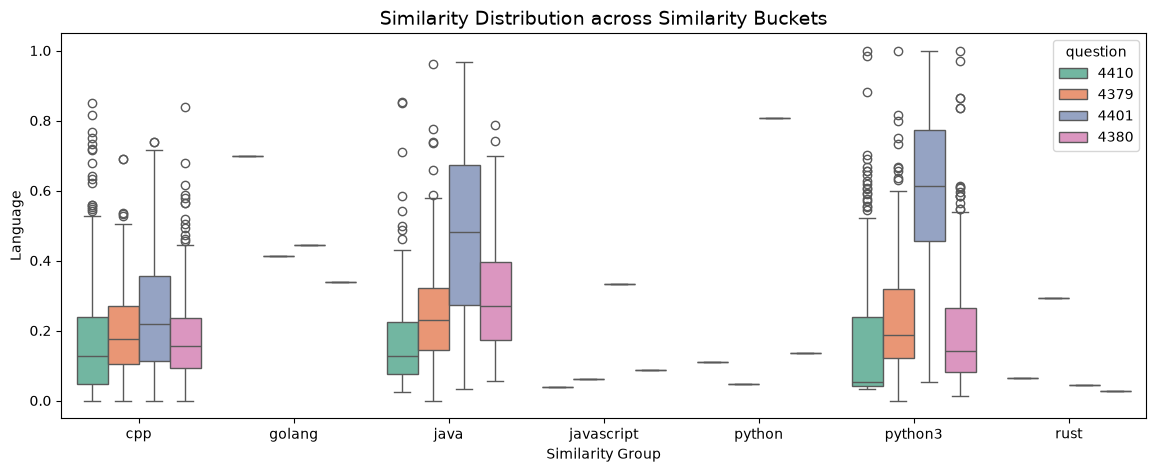

In [23]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='language', y='similarity', hue='question', palette='Set2')

plt.title('Similarity Distribution across Similarity Buckets', fontsize=14)
plt.xlabel('Similarity Group')
plt.ylabel('Language')
plt.show()
